# V-BReE accuracy assesments

## 1. Data load and workspace prepration

In [1]:
# %pip install scipy

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns

## 1.1. Load sample and primary results

In [ ]:
sample = pd.read_csv("../data/mmlu_pro_12_cat_250_sample_20260306.csv")

data = pd.read_csv('../data/full_sample_results/v-bree_mmlupro_test_0_3000_20260306_final.csv')

merged = pd.merge(data, sample[["question_id", "answer"]], c)

chosen_responses = merged[merged["chosen_response"] == True]

display(chosen_responses.head(5))

,Unnamed: 0,id,iteration,model,question,choices,domain,prompt_tokens,previous_answer,updated_answer,selected_choice,response_tokens,scoring_model,score,score_moving_avg,score_moving_variance,chosen_response,confidence_score,question_id,answer
7,7,3206,7,Qwen/Qwen2.5-7B-Instruct:together,The geneticist Mary Lyon hypothesized the exis...,"['In the early female embryo, one copy of the ...",biology,408,"Barr bodies are the condensed, inactive X chro...","Barr bodies are the condensed, inactive X chro...",B,157,meta-llama/Llama-3.1-8B-Instruct:cerebras,90.0,81.666667,58.333333,True,0.445475,3206,B
34,34,3053,8,Qwen/Qwen2.5-7B-Instruct:together,All of the following are examples of events th...,['the potential mates experience geographic is...,biology,305,Interspecific breeding is prevented by mechani...,All of the following are examples of events th...,D,104,meta-llama/Llama-3.1-8B-Instruct:cerebras,100.0,91.666667,58.333333,True,0.500000,3053,D
61,61,3476,10,Qwen/Qwen2.5-7B-Instruct:together,What prevents the stomach from being digested ...,['The stomach has a high permeability to hydro...,biology,453,The stomach protects itself from self‑digestio...,The stomach protects itself from self-digestio...,H,126,meta-llama/Llama-3.1-8B-Instruct:cerebras,95.0,90.333333,25.333333,True,0.964195,3476,H
75,75,3268,9,meta-llama/Llama-3.1-8B-Instruct:cerebras,Which of the following is an example of a cline?,['Males of some species have long antlers to f...,biology,604,"A cline is a gradual, continuous change in a t...","A cline is a gradual, continuous change in a t...",F,64,openai/gpt-oss-20b:groq,94.0,89.666667,20.333333,True,1.201435,3268,H
107,107,3001,12,Qwen/Qwen2.5-7B-Instruct:together,Which of the following is a correct statement ...,['Living cells of the phloem provide the main ...,biology,382,The evaporation of water from leaf mesophyll c...,The evaporation of water from leaf mesophyll c...,H,125,meta-llama/Llama-3.1-8B-Instruct:cerebras,80.0,78.333333,8.333333,True,1.514773,3001,H


## 1.2. Load individual model results

In [3]:
gpt_data = pd.read_csv('../data/full_sample_results/gpt_mmlupro_test_0_3000_20260306.csv')
qwen_data = pd.read_csv('../data/full_sample_results/qwen_mmlupro_test_0_3000_20260307.csv')
llama_data = pd.read_csv('../data/full_sample_results/llama_mmlupro_test_0_3000_20260307.csv')

gpt_merged = pd.merge(gpt_data, sample[["question_id", "answer"]], left_on = "id", right_on = "question_id", how = "left")
qwen_merged = pd.merge(qwen_data, sample[["question_id", "answer"]], left_on = "id", right_on = "question_id", how = "left")
llama_merged = pd.merge(llama_data, sample[["question_id", "answer"]], left_on = "id", right_on = "question_id", how = "left")

## 2. Accuracy results

## 2.1. Overall accuracy

In [4]:
overall_accuracy = (chosen_responses["answer"] == chosen_responses["selected_choice"]).mean()
print(overall_accuracy)

0.6464511829390204


## 2.2. Accuracy compared to constituent models - Overall

Ensemble Accuracy: 0.65
GPT Accuracy: 0.66
Qwen Accuracy: 0.51
Llama Accuracy: 0.39


Text(0, 0.5, 'Accuracy')

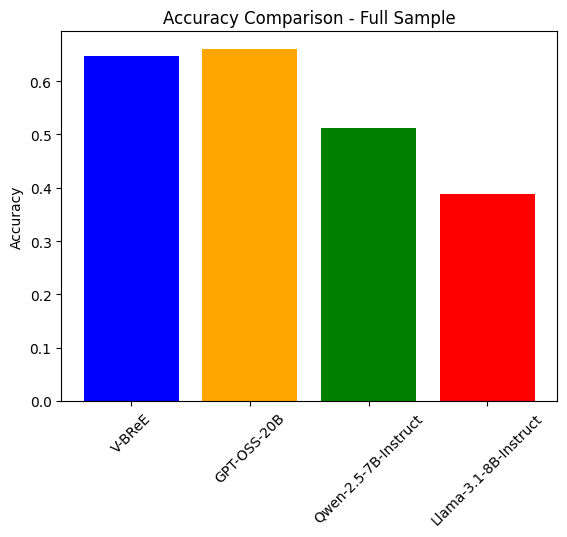

In [5]:
# accuracy_df = pd.DataFrame({
#     "Model": ["GPT-OSS-20B", "Qwen-2.5-7B-Instruct", "Llama-3.1-8B-Instruct"],
#     "Accuracy": [
#         (gpt_merged['answer'] == gpt_merged['selected_choice']).mean(),
#         (qwen_merged['answer'] == qwen_merged['selected_choice']).mean(),
#         (llama_merged['answer'] == llama_merged['selected_choice']).mean()
#     ]
# })

accuracy_df = pd.DataFrame({
    "Model": ["V-BReE", "GPT-OSS-20B", "Qwen-2.5-7B-Instruct", "Llama-3.1-8B-Instruct"],
    "Accuracy": [
        (chosen_responses['answer'] == chosen_responses['selected_choice']).mean(),
        (gpt_merged['answer'] == gpt_merged['selected_choice']).mean(),
        (qwen_merged['answer'] == qwen_merged['selected_choice']).mean(),
        (llama_merged['answer'] == llama_merged['selected_choice']).mean()
    ]
})

print(f"Ensemble Accuracy: {accuracy_df.loc[accuracy_df['Model'] == 'V-BReE', 'Accuracy'].values[0]:.2f}")
print(f"GPT Accuracy: {accuracy_df.loc[accuracy_df['Model'] == 'GPT-OSS-20B', 'Accuracy'].values[0]:.2f}")
print(f"Qwen Accuracy: {accuracy_df.loc[accuracy_df['Model'] == 'Qwen-2.5-7B-Instruct', 'Accuracy'].values[0]:.2f}")
print(f"Llama Accuracy: {accuracy_df.loc[accuracy_df['Model'] == 'Llama-3.1-8B-Instruct', 'Accuracy'].values[0]:.2f}")

##PLOTTING ACCURACY COMPARISON
plt.bar(accuracy_df["Model"], accuracy_df["Accuracy"], color=['blue', 'orange', 'green', 'red'])
# plt.bar(accuracy_df["Model"], accuracy_df["Accuracy"], color=['orange', 'green', 'red'])
plt.title("Accuracy Comparison - Full Sample")
##ROTATE X-AXIS LABELS FOR BETTER READABILITY
plt.xticks(rotation=45)
# plt.title("Constituent Model Accuracy Comparison - Full Sample")
plt.ylabel("Accuracy")

## 2.3. Non-error accuracy

In [6]:
error_cases = merged["id"][merged["updated_answer"] == "Error"].unique()

non_error_cases = merged["id"][~merged["id"].isin(error_cases)].unique()
print(len(non_error_cases))

non_error_responses = merged[merged["id"].isin(non_error_cases)]
non_error_chosen_responses = non_error_responses[non_error_responses["chosen_response"] == True]
non_error_accuracy = (non_error_chosen_responses["answer"] == non_error_chosen_responses["selected_choice"]).mean()
print(non_error_accuracy)

2117
0.6751652502360718


In [8]:
##RANDOMLY SAMPLE ID OF 100 ERROR CASES
error_sample_ids = np.random.choice(error_cases, size=100, replace=False)
print(error_sample_ids.tolist())

[3285, 10290, 1129, 1215, 10609, 7634, 10756, 3694, 12013, 4760, 1166, 4982, 11604, 4713, 1354, 8964, 1632, 3747, 10735, 11856, 2994, 226, 4621, 3081, 9243, 1646, 10431, 7306, 11123, 12109, 12053, 3652, 390, 12183, 10803, 10366, 4093, 8924, 4188, 9972, 11789, 135, 11787, 3152, 8921, 10280, 3650, 1398, 7268, 7043, 6833, 4756, 4966, 564, 4580, 4757, 11900, 540, 10010, 11958, 10766, 4942, 10002, 11902, 8165, 10704, 1638, 1579, 11218, 599, 4536, 4335, 8710, 8318, 11586, 12062, 2214, 102, 11506, 11292, 8089, 11181, 11422, 10670, 10626, 2983, 3781, 7348, 10677, 10777, 9130, 3998, 9132, 2950, 3579, 10859, 1613, 200, 12074, 7992]


In [269]:
print(len(non_error_chosen_responses))

2118


In [270]:
##NOTE - THESE ARE NON ERROR CASES FOR V-BREE, NOT FOR THE PARTICULAR MODEL - FOR APPLES TO APPLES COMPARISON
gpt_non_error_responses = gpt_merged[gpt_merged["id"].isin(non_error_cases)]
qwen_non_error_responses = qwen_merged[qwen_merged["id"].isin(non_error_cases)]
llama_non_error_responses = llama_merged[llama_merged["id"].isin(non_error_cases)]

## 2.4. Non-error accuracy comparison

Ensemble Accuracy: 0.68
GPT Accuracy: 0.71
Qwen Accuracy: 0.57
Llama Accuracy: 0.44


Text(0, 0.5, 'Accuracy')

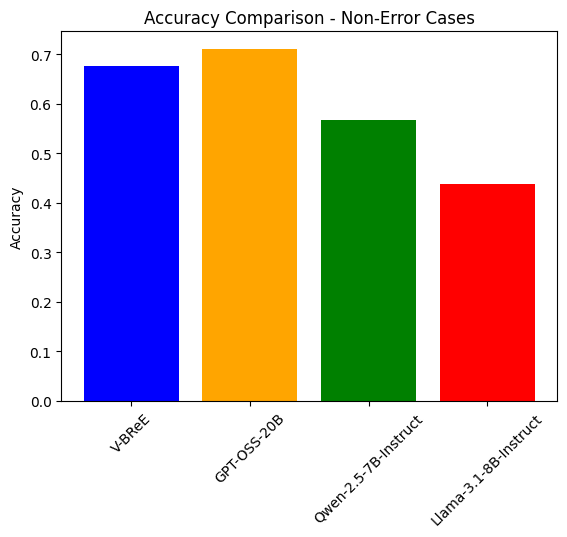

In [271]:
ne_accuracy_df = pd.DataFrame({
    "Model": ["V-BReE", "GPT-OSS-20B", "Qwen-2.5-7B-Instruct", "Llama-3.1-8B-Instruct"],
    "Accuracy": [
        (non_error_chosen_responses['answer'] == non_error_chosen_responses['selected_choice']).mean(),
        (gpt_non_error_responses['answer'] == gpt_non_error_responses['selected_choice']).mean(),
        (qwen_non_error_responses['answer'] == qwen_non_error_responses['selected_choice']).mean(),
        (llama_non_error_responses['answer'] == llama_non_error_responses['selected_choice']).mean()
    ]
})

print(f"Ensemble Accuracy: {ne_accuracy_df.loc[accuracy_df['Model'] == 'V-BReE', 'Accuracy'].values[0]:.2f}")
print(f"GPT Accuracy: {ne_accuracy_df.loc[accuracy_df['Model'] == 'GPT-OSS-20B', 'Accuracy'].values[0]:.2f}")
print(f"Qwen Accuracy: {ne_accuracy_df.loc[accuracy_df['Model'] == 'Qwen-2.5-7B-Instruct', 'Accuracy'].values[0]:.2f}")
print(f"Llama Accuracy: {ne_accuracy_df.loc[accuracy_df['Model'] == 'Llama-3.1-8B-Instruct', 'Accuracy'].values[0]:.2f}")

##PLOTTING ACCURACY COMPARISON
plt.bar(ne_accuracy_df["Model"], ne_accuracy_df["Accuracy"], color=['blue', 'orange', 'green', 'red'])
##ROTATE X-AXIS LABELS FOR BETTER READABILITY
plt.xticks(rotation=45)
plt.title("Accuracy Comparison - Non-Error Cases")
plt.ylabel("Accuracy")

## 2.5. Accuracy by domain

In [272]:
accuracy_by_domain = chosen_responses.groupby("domain").apply(lambda x: (x["answer"] == x["selected_choice"]).mean()).sort_values(ascending=False)
print(accuracy_by_domain)

domain
math                0.848000
physics             0.800000
chemistry           0.768000
business            0.764000
biology             0.752000
computer science    0.685259
psychology          0.684000
economics           0.632000
engineering         0.560000
philosophy          0.516000
history             0.472000
law                 0.276000
dtype: float64


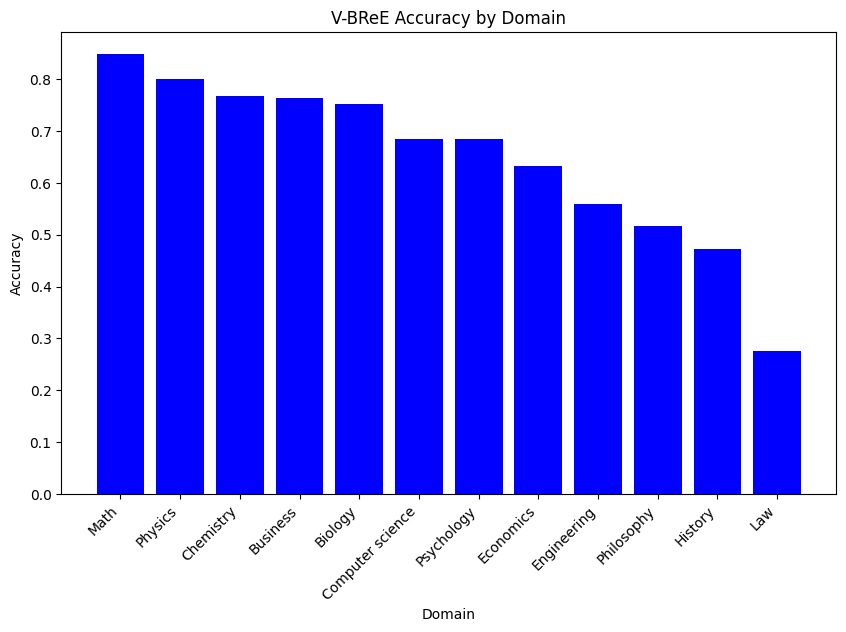

In [273]:
plt.figure(figsize=(10, 6))
plt.bar([x.capitalize() for x in accuracy_by_domain.index], accuracy_by_domain.values, color = 'blue')
plt.title('V-BReE Accuracy by Domain')
plt.xlabel('Domain')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Accuracy')
plt.show()

## 2.6. Accuracy by domain

In [274]:
##CREATE A TABLE OF ACCURACY BY DOMAIN FOR NON-ERROR CASES FOR ALL MODELS
gpt_accuracy_by_domain = gpt_merged.groupby("domain").apply(lambda x: (x["answer"] == x["selected_choice"]).mean()).sort_values(ascending=False)
qwen_accuracy_by_domain = qwen_merged.groupby("domain").apply(lambda x: (x["answer"] == x["selected_choice"]).mean()).sort_values(ascending=False)
llama_accuracy_by_domain = llama_merged.groupby("domain").apply(lambda x: (x["answer"] == x["selected_choice"]).mean()).sort_values(ascending=False)

accuracy_by_domain_df = pd.DataFrame(accuracy_by_domain).reset_index().rename(columns={0: 'V-BReE Accuracy'})

accuracy_by_domain_df["GPT-OSS-20B Accuracy"] = gpt_accuracy_by_domain.reindex(accuracy_by_domain_df["domain"]).values
accuracy_by_domain_df["Qwen-2.5-7B-Instruct Accuracy"] = qwen_accuracy_by_domain.reindex(accuracy_by_domain_df["domain"]).values
accuracy_by_domain_df["Llama-3.1-8B-Instruct Accuracy"] = llama_accuracy_by_domain.reindex(accuracy_by_domain_df["domain"]).values

accuracy_by_domain_df.rename(columns={"domain": "Domain"}, inplace=True)
accuracy_by_domain_df["Domain"] = accuracy_by_domain_df["Domain"].str.capitalize()

display(accuracy_by_domain_df)

,Domain,V-BReE Accuracy,GPT-OSS-20B Accuracy,Qwen-2.5-7B-Instruct Accuracy,Llama-3.1-8B-Instruct Accuracy
0,Math,0.848000,0.856,0.612,0.364
1,Physics,0.800000,0.764,0.476,0.288
2,Chemistry,0.768000,0.760,0.444,0.316
3,Business,0.764000,0.716,0.620,0.336
4,Biology,0.752000,0.860,0.740,0.708
5,Computer science,0.685259,0.752,0.484,0.328
6,Psychology,0.684000,0.712,0.628,0.556
7,Economics,0.632000,0.756,0.588,0.500
8,Engineering,0.560000,0.384,0.360,0.280
9,Philosophy,0.516000,0.508,0.444,0.328


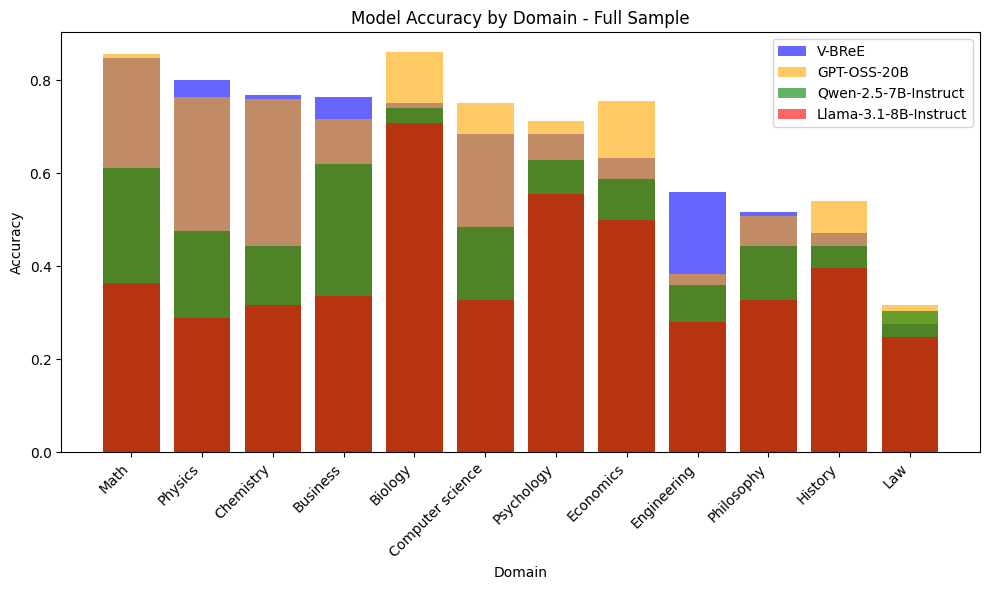

In [275]:
fig, ax = plt.subplots(figsize=(10, 6))
v_bree_bars = ax.bar(accuracy_by_domain_df["Domain"], height=accuracy_by_domain_df["V-BReE Accuracy"], label='V-BReE', alpha=0.6, color='blue')
gpt_bars = ax.bar(accuracy_by_domain_df["Domain"], height=accuracy_by_domain_df["GPT-OSS-20B Accuracy"], label='GPT-OSS-20B', alpha=0.6, color='orange')
qwen_bars = ax.bar(accuracy_by_domain_df["Domain"], height=accuracy_by_domain_df["Qwen-2.5-7B-Instruct Accuracy"], label='Qwen-2.5-7B-Instruct', alpha=0.6, color='green')
llama_bars = ax.bar(accuracy_by_domain_df["Domain"], height=accuracy_by_domain_df["Llama-3.1-8B-Instruct Accuracy"], label='Llama-3.1-8B-Instruct', alpha=0.6, color='red')

ax.set_title('Model Accuracy by Domain - Full Sample')
ax.set_xlabel('Domain')
ax.set_xticks(range(len(accuracy_by_domain_df["Domain"])))
ax.set_xticklabels(accuracy_by_domain_df["Domain"], rotation=45, ha='right')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

## 2.7. Non-error Accuracy by Domain

In [276]:
##CREATE A TABLE OF ACCURACY BY DOMAIN FOR NON-ERROR CASES
v_bree_ne_accuracy_by_domain = non_error_chosen_responses.groupby("domain").apply(lambda x: (x["answer"] == x["selected_choice"]).mean()).sort_values(ascending=False)
gpt_ne_accuracy_by_domain = gpt_non_error_responses.groupby("domain").apply(lambda x: (x["answer"] == x["selected_choice"]).mean()).sort_values(ascending=False)
qwen_ne_accuracy_by_domain = qwen_non_error_responses.groupby("domain").apply(lambda x: (x["answer"] == x["selected_choice"]).mean()).sort_values(ascending=False)
llama_ne_accuracy_by_domain = llama_non_error_responses.groupby("domain").apply(lambda x: (x["answer"] == x["selected_choice"]).mean()).sort_values(ascending=False)

ne_accuracy_by_domain_df = pd.DataFrame(v_bree_ne_accuracy_by_domain).reset_index().rename(columns={0: 'V-BReE Accuracy'})

ne_accuracy_by_domain_df["GPT-OSS-20B Accuracy"] = gpt_ne_accuracy_by_domain.reindex(ne_accuracy_by_domain_df["domain"]).values
ne_accuracy_by_domain_df["Qwen-2.5-7B-Instruct Accuracy"] = qwen_ne_accuracy_by_domain.reindex(ne_accuracy_by_domain_df["domain"]).values
ne_accuracy_by_domain_df["Llama-3.1-8B-Instruct Accuracy"] = llama_ne_accuracy_by_domain.reindex(ne_accuracy_by_domain_df["domain"]).values

ne_accuracy_by_domain_df.rename(columns={"domain": "Domain"}, inplace=True)
ne_accuracy_by_domain_df["Domain"] = ne_accuracy_by_domain_df["Domain"].str.capitalize()

display(ne_accuracy_by_domain_df)

,Domain,V-BReE Accuracy,GPT-OSS-20B Accuracy,Qwen-2.5-7B-Instruct Accuracy,Llama-3.1-8B-Instruct Accuracy
0,Math,0.911765,0.917647,0.705882,0.400000
1,Physics,0.824561,0.818713,0.561404,0.339181
2,Business,0.822086,0.803681,0.736196,0.429448
3,Chemistry,0.819549,0.827068,0.511278,0.368421
4,Computer science,0.741176,0.792899,0.544379,0.372781
5,Biology,0.732673,0.866337,0.727723,0.707921
6,Psychology,0.703704,0.722222,0.657407,0.569444
7,Economics,0.663415,0.770732,0.619512,0.526829
8,Engineering,0.634146,0.585366,0.426829,0.329268
9,Philosophy,0.549296,0.530516,0.474178,0.361502


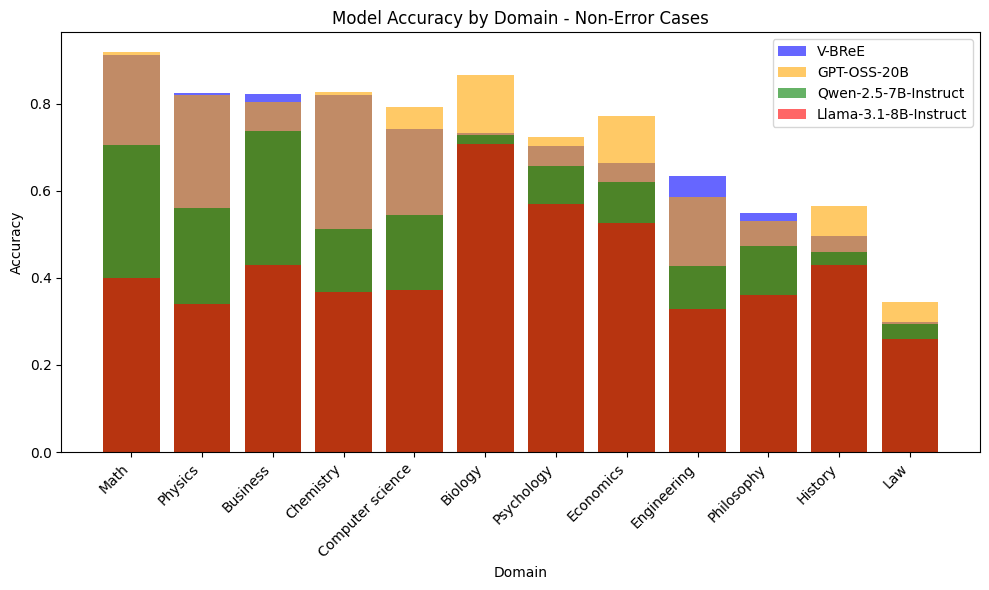

In [277]:
fig, ax = plt.subplots(figsize=(10, 6))
v_bree_bars = ax.bar(ne_accuracy_by_domain_df["Domain"], height=ne_accuracy_by_domain_df["V-BReE Accuracy"], label='V-BReE', alpha=0.6, color='blue')
gpt_bars = ax.bar(ne_accuracy_by_domain_df["Domain"], height=ne_accuracy_by_domain_df["GPT-OSS-20B Accuracy"], label='GPT-OSS-20B', alpha=0.6, color='orange')
qwen_bars = ax.bar(ne_accuracy_by_domain_df["Domain"], height=ne_accuracy_by_domain_df["Qwen-2.5-7B-Instruct Accuracy"], label='Qwen-2.5-7B-Instruct', alpha=0.6, color='green')
llama_bars = ax.bar(ne_accuracy_by_domain_df["Domain"], height=ne_accuracy_by_domain_df["Llama-3.1-8B-Instruct Accuracy"], label='Llama-3.1-8B-Instruct', alpha=0.6, color='red')

ax.set_title('Model Accuracy by Domain - Non-Error Cases')
ax.set_xlabel('Domain')
ax.set_xticks(range(len(ne_accuracy_by_domain_df["Domain"])))
ax.set_xticklabels(ne_accuracy_by_domain_df["Domain"], rotation=45, ha='right')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

# 3. What makes engineering different?

## 3.1. Error percentage by category

In [278]:
##GET ERROR RATE OF RESPONSES BY DOMAIN
error_rate_by_domain = merged.groupby("domain").apply(lambda x: (x["updated_answer"] == "Error").mean()).sort_values(ascending=False)
error_rate_by_domain_df = pd.DataFrame(error_rate_by_domain).reset_index().rename(columns={0: 'Error Rate'})
error_rate_by_domain_df.rename(columns={"domain": "Domain"}, inplace=True)
error_rate_by_domain_df["Domain"] = error_rate_by_domain_df["Domain"].str.capitalize()

display(error_rate_by_domain_df)

,Domain,Error Rate
0,Engineering,0.155474
1,Chemistry,0.084672
2,Math,0.056173
3,Business,0.051948
4,Physics,0.043961
5,Computer science,0.038154
6,Biology,0.030198
7,Law,0.026700
8,Economics,0.024536
9,History,0.018390


,Domain,Error Rate,V-BReE vs GPT Accuracy Diff
0,Engineering,0.155474,0.176000
1,Chemistry,0.084672,0.008000
2,Math,0.056173,-0.008000
3,Business,0.051948,0.048000
4,Physics,0.043961,0.036000
5,Computer science,0.038154,-0.066741
6,Biology,0.030198,-0.108000
7,Law,0.026700,-0.040000
8,Economics,0.024536,-0.124000
9,History,0.018390,-0.068000


Pearson correlation: 0.79, p-value: 0.0024


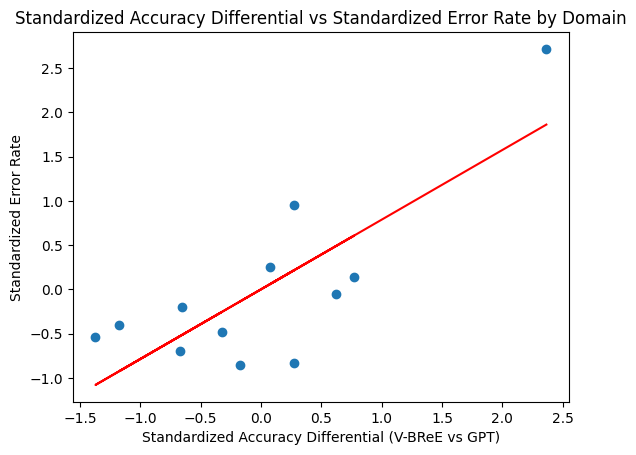

In [279]:
##CALCULATE ACCURACY DIFFERENTIAL BETWEEN GPT AND V-BREE BY DOMAIN
accuracy_by_domain_df["V-BReE vs GPT Accuracy Diff"] = accuracy_by_domain_df["V-BReE Accuracy"] - accuracy_by_domain_df["GPT-OSS-20B Accuracy"]
accuracy_by_domain_df["V-BReE vs Qwen Accuracy Diff"] = accuracy_by_domain_df["V-BReE Accuracy"] - accuracy_by_domain_df["Qwen-2.5-7B-Instruct Accuracy"]
accuracy_by_domain_df["V-BReE vs Llama Accuracy Diff"] = accuracy_by_domain_df["V-BReE Accuracy"] - accuracy_by_domain_df["Llama-3.1-8B-Instruct Accuracy"]

accuracy_error_rate_by_domain = pd.merge(error_rate_by_domain_df, accuracy_by_domain_df[["Domain", "V-BReE vs GPT Accuracy Diff"]], on = "Domain", how = "left")


display(accuracy_error_rate_by_domain)

acc_err_diff_std = pd.DataFrame(columns = ["Domain", "Standardized Error Rate", "Standardized Accuracy Diff"])
acc_err_diff_std["Domain"] = accuracy_error_rate_by_domain["Domain"]
acc_err_diff_std["Standardized Error Rate"] = (accuracy_error_rate_by_domain["Error Rate"] - accuracy_error_rate_by_domain["Error Rate"].mean()) / accuracy_error_rate_by_domain["Error Rate"].std()
acc_err_diff_std["Standardized Accuracy Diff"] = (accuracy_error_rate_by_domain["V-BReE vs GPT Accuracy Diff"] - accuracy_error_rate_by_domain["V-BReE vs GPT Accuracy Diff"].mean()) / accuracy_error_rate_by_domain["V-BReE vs GPT Accuracy Diff"].std()

corr, p = stats.pearsonr(acc_err_diff_std["Standardized Accuracy Diff"], acc_err_diff_std["Standardized Error Rate"])

print(f"Pearson correlation: {corr:.2f}, p-value: {p:.4f}")


##PLOT RELATIONSHIP BETWEEN STANDARDIZED ACCURACY DIFFERENTIAL AND STANDARDIZED ERROR RATE BY DOMAIN
m, b = np.polyfit(acc_err_diff_std["Standardized Accuracy Diff"], acc_err_diff_std["Standardized Error Rate"], 1)

plt.scatter(acc_err_diff_std["Standardized Accuracy Diff"], acc_err_diff_std["Standardized Error Rate"])
plt.plot(acc_err_diff_std["Standardized Accuracy Diff"], m * acc_err_diff_std["Standardized Accuracy Diff"] + b, color='red')  # Add line of best fit
plt.title("Standardized Accuracy Differential vs Standardized Error Rate by Domain")
plt.xlabel("Standardized Accuracy Differential (V-BReE vs GPT)")
plt.ylabel("Standardized Error Rate")
plt.show()

### 3.2.1. Check strength of relationship with Engineering dropped

In [280]:
non_eng_corr = acc_err_diff_std[acc_err_diff_std["Domain"] != "Engineering"]
non_eng_corr, non_eng_p = stats.pearsonr(non_eng_corr["Standardized Accuracy Diff"], non_eng_corr["Standardized Error Rate"])

print(f"Pearson correlation: {non_eng_corr:.2f}, p-value: {non_eng_p:.4f}")

Pearson correlation: 0.43, p-value: 0.1817


## 3.3. Investigating if the relationship between accuracy differential and error rate is driven by more iterations

---

It does not seem to have a relationship with median iteration count.

It does not seem to have a relationship with mean iteration count.

              Domain  Error Rate  V-BReE vs GPT Accuracy Diff  \
0        Engineering    0.155474                     0.176000   
1          Chemistry    0.084672                     0.008000   
2               Math    0.056173                    -0.008000   
3           Business    0.051948                     0.048000   
4            Physics    0.043961                     0.036000   
5   Computer science    0.038154                    -0.066741   
6            Biology    0.030198                    -0.108000   
7                Law    0.026700                    -0.040000   
8          Economics    0.024536                    -0.124000   
9            History    0.018390                    -0.068000   
10        Philosophy    0.012611                     0.008000   
11        Psychology    0.011997                    -0.028000   

    Median Iterations  
0                18.0  
1                14.0  
2                22.0  
3                23.0  
4                14.0  
5         

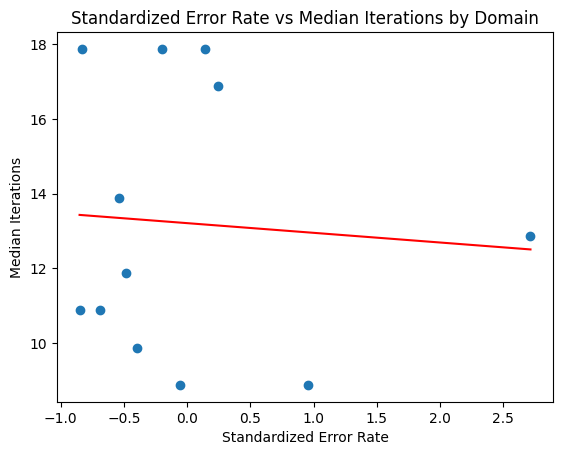

In [281]:
##MEDIAN ITERATION COUNT CHECK
##ADD MEDIAN NUMBER OF ITERATIONS TO THE ACCURACY DIFF / ERRORS BY DOMAIN TABLE
max_iter_table = merged[merged["iteration"] == merged.groupby("id")["iteration"].transform("max")]
median_iterations_by_domain = max_iter_table.groupby("domain")["iteration"].median().reset_index().rename(columns={"iteration": "Median Iterations", "domain": "Domain"})
median_iterations_by_domain.rename(columns={"domain": "Domain"}, inplace=True)
median_iterations_by_domain["Domain"] = median_iterations_by_domain["Domain"].str.capitalize()

err_rate_acc_diff_iters_df = pd.merge(accuracy_error_rate_by_domain, median_iterations_by_domain, on = "Domain", how = "left")
print(err_rate_acc_diff_iters_df)

std_err_rate_iters_df = pd.DataFrame(columns = ["Domain", "Standardized Error Rate", "Median Iterations"])
std_err_rate_iters_df["Domain"] = err_rate_acc_diff_iters_df["Domain"]
std_err_rate_iters_df["Standardized Error Rate"] = (err_rate_acc_diff_iters_df["Error Rate"] - err_rate_acc_diff_iters_df["Error Rate"].mean()) / err_rate_acc_diff_iters_df["Error Rate"].std()
std_err_rate_iters_df["Median Iterations"] = err_rate_acc_diff_iters_df["Median Iterations"] - err_rate_acc_diff_iters_df["Median Iterations"].mean() / err_rate_acc_diff_iters_df["Median Iterations"].std()

corr_iters, p_iters = stats.pearsonr(std_err_rate_iters_df["Standardized Error Rate"], std_err_rate_iters_df["Median Iterations"])
print(f"Pearson correlation: {corr_iters:.2f}, p-value: {p_iters:.4f}")

##PLOT RELATIONSHIP BETWEEN STANDARDIZED ERROR RATE AND MEDIAN ITERATIONS BY DOMAIN
m_iters, b_iters = np.polyfit(std_err_rate_iters_df["Standardized Error Rate"], std_err_rate_iters_df["Median Iterations"], 1)
plt.scatter(std_err_rate_iters_df["Standardized Error Rate"], std_err_rate_iters_df["Median Iterations"])
plt.plot(std_err_rate_iters_df["Standardized Error Rate"], m_iters * std_err_rate_iters_df["Standardized Error Rate"] + b_iters, color='red')  # Add line of best fit
plt.title("Standardized Error Rate vs Median Iterations by Domain")
plt.xlabel("Standardized Error Rate")
plt.ylabel("Median Iterations")
plt.show()


              Domain  Error Rate  V-BReE vs GPT Accuracy Diff  Mean Iterations
0        Engineering    0.155474                     0.176000           18.656
1          Chemistry    0.084672                     0.008000           15.440
2               Math    0.056173                    -0.008000           18.796
3           Business    0.051948                     0.048000           20.868
4            Physics    0.043961                     0.036000           15.196
5   Computer science    0.038154                    -0.066741           21.420
6            Biology    0.030198                    -0.108000           16.352
7                Law    0.026700                    -0.040000           18.176
8          Economics    0.024536                    -0.124000           18.400
9            History    0.018390                    -0.068000           16.836
10        Philosophy    0.012611                     0.008000           21.520
11        Psychology    0.011997                    

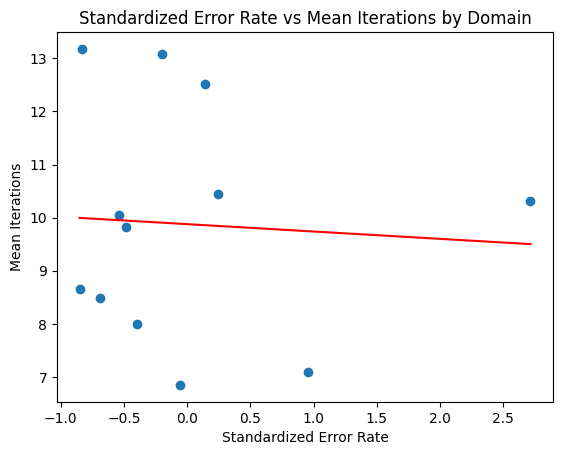

In [282]:
##MEAN ITERATION COUNT CHECK
##ADD MEDIAN NUMBER OF ITERATIONS TO THE ACCURACY DIFF / ERRORS BY DOMAIN TABLE
mean_iterations_by_domain = max_iter_table.groupby("domain")["iteration"].mean().reset_index().rename(columns={"iteration": "Mean Iterations", "domain": "Domain"})
mean_iterations_by_domain.rename(columns={"domain": "Domain"}, inplace=True)
mean_iterations_by_domain["Domain"] = mean_iterations_by_domain["Domain"].str.capitalize()

err_rate_acc_diff_mean_iters_df = pd.merge(accuracy_error_rate_by_domain, mean_iterations_by_domain, on = "Domain", how = "left")
print(err_rate_acc_diff_mean_iters_df)

std_err_rate_mean_iters_df = pd.DataFrame(columns = ["Domain", "Standardized Error Rate", "Mean Iterations"])
std_err_rate_mean_iters_df["Domain"] = err_rate_acc_diff_mean_iters_df["Domain"]
std_err_rate_mean_iters_df["Standardized Error Rate"] = (err_rate_acc_diff_mean_iters_df["Error Rate"] - err_rate_acc_diff_mean_iters_df["Error Rate"].mean()) / err_rate_acc_diff_mean_iters_df["Error Rate"].std()
std_err_rate_mean_iters_df["Mean Iterations"] = err_rate_acc_diff_mean_iters_df["Mean Iterations"] - err_rate_acc_diff_mean_iters_df["Mean Iterations"].mean() / err_rate_acc_diff_mean_iters_df["Mean Iterations"].std()

print(std_err_rate_mean_iters_df)

corr_mean_iters, p_mean_iters = stats.pearsonr(std_err_rate_mean_iters_df["Standardized Error Rate"], std_err_rate_mean_iters_df["Mean Iterations"])
print(f"Pearson correlation: {corr_mean_iters:.2f}, p-value: {p_mean_iters:.4f}")

##PLOT RELATIONSHIP BETWEEN STANDARDIZED ERROR RATE AND MEDIAN ITERATIONS BY DOMAIN
m_mean_iters, b_mean_iters = np.polyfit(std_err_rate_mean_iters_df["Standardized Error Rate"], std_err_rate_mean_iters_df["Mean Iterations"], 1)
plt.scatter(std_err_rate_mean_iters_df["Standardized Error Rate"], std_err_rate_mean_iters_df["Mean Iterations"])
plt.plot(std_err_rate_mean_iters_df["Standardized Error Rate"], m_mean_iters * std_err_rate_mean_iters_df["Standardized Error Rate"] + b_mean_iters, color='red')  # Add line of best fit
plt.title("Standardized Error Rate vs Mean Iterations by Domain")
plt.xlabel("Standardized Error Rate")
plt.ylabel("Mean Iterations")
plt.show()

## 3.4. Examining results at the end of each cycle
Does accuracy improve or degrade across cycles.  Could errors be "resetting" the consensus process, allowing the ensemble to reach a quick consensus without "overthinking"?

Text(0.5, 0, 'Iteration Cycle')

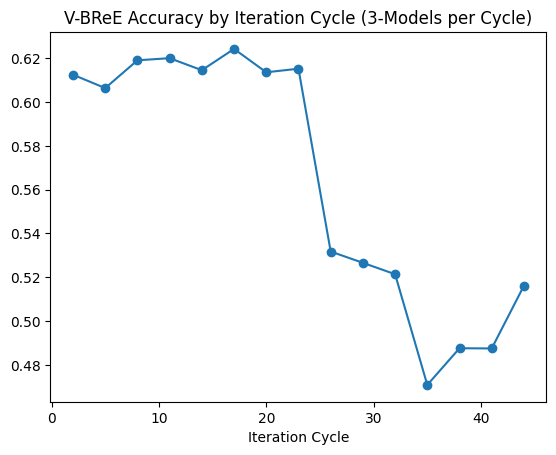

In [283]:
##MERGED = ALL DATA WITH ANSWERS
cycle_endpoints = merged[(merged["iteration"] + 1) % 3 == 0]

##PLOT ACCURACY BY ITERATION CYCLE
accuracy_by_cycle = cycle_endpoints.groupby("iteration")["answer"].apply(lambda x: (x == cycle_endpoints.loc[x.index, "selected_choice"]).mean())
plt.plot(accuracy_by_cycle.index, accuracy_by_cycle.values, marker='o')
plt.title("V-BReE Accuracy by Iteration Cycle (3-Models per Cycle)")
plt.xlabel("Iteration Cycle")

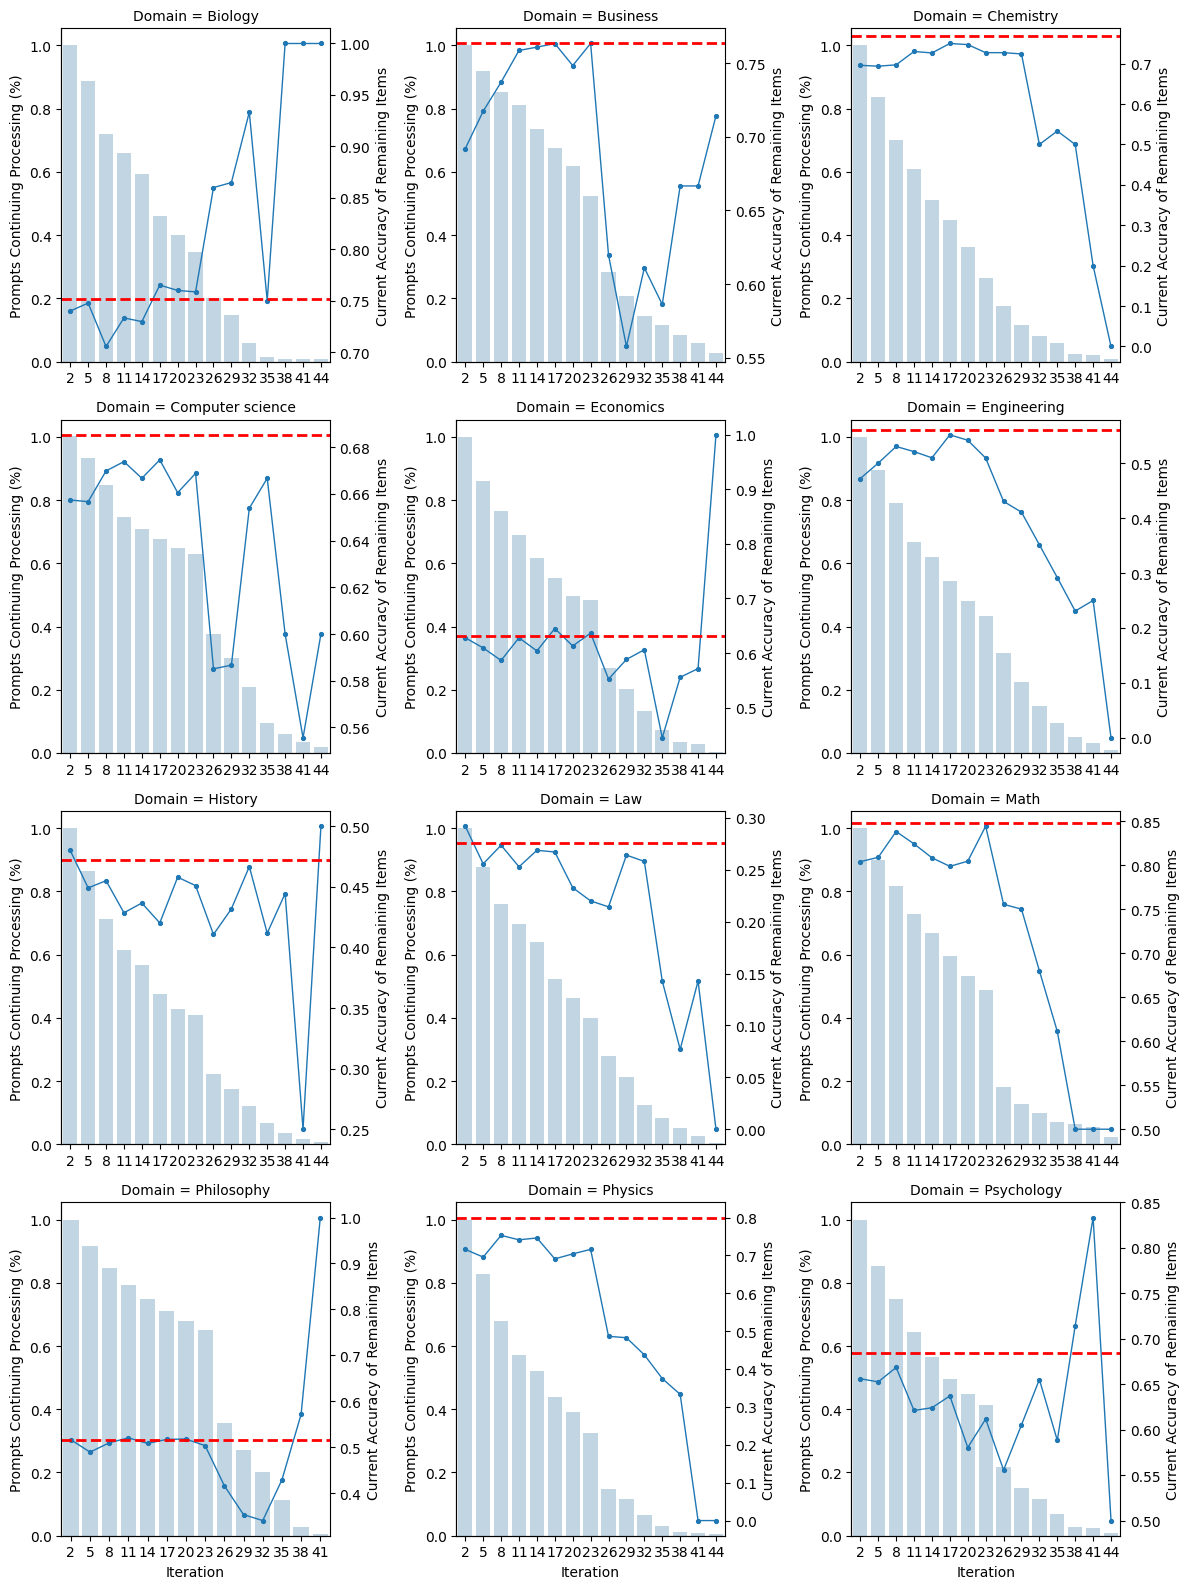

In [284]:
##PLOT GRID OF ACCURACY BY ITERATION CYCLE FOR EACH DOMAIN
def plot_accuracy_by_cycle(data, **kwargs):
    #fig, ax1 = plt.subplots(figsize=(12, 8))
    ax1 = plt.gca()
    ax2 = ax1.twinx()

    sns.barplot(data=data, x=kwargs['x'], y=kwargs['y2'], ax=ax1, alpha=0.3)
    sns.pointplot(data=data, x=kwargs['x'], y=kwargs['y1'], markersize = 3, linewidth = 1, marker='o', ax=ax2)
    ax2.axhline(y=data[kwargs['y3']].iloc[0], color='red', linestyle='--', label='Overall Domain Accuracy', linewidth = 2)
    

##ACCURACY OF QUESTIONS THAT MAKE IT TO EACH CYCLE ENDPOINT AT THAT POINT (NOT AT FINAL ANSWER)
domain_cycle_accuracy = cycle_endpoints.groupby(["domain", "iteration"])["answer"].apply(lambda x: (x == cycle_endpoints.loc[x.index, "selected_choice"]).mean()).reset_index().rename(columns={"answer": "Accuracy"})
q_count_by_domain = merged["id"].groupby(merged["domain"]).nunique()

iter_counts_by_domain = cycle_endpoints.groupby(["domain", "iteration"])[["iteration"]].count()
iter_counts_by_domain.rename(columns={"iteration": "itercount"}, inplace=True)
iter_counts_by_domain["domain"] = iter_counts_by_domain.index.get_level_values("domain")
iter_counts_by_domain["iteration"] = iter_counts_by_domain.index.get_level_values("iteration")
iter_counts_by_domain.reset_index(drop=True, inplace=True)

iter_counts_by_domain["completed_prompts"] = q_count_by_domain.reindex(iter_counts_by_domain["domain"]).values - iter_counts_by_domain["itercount"]
iter_counts_by_domain["pct_remaining"] = (q_count_by_domain.reindex(iter_counts_by_domain["domain"]).values - iter_counts_by_domain["completed_prompts"]) / q_count_by_domain.reindex(iter_counts_by_domain["domain"]).values


# iter_counts_by_domain["remaining_this_cycle"] = iter_counts_by_domain["completed_prompts"] - iter_counts_by_domain["completed_prompts"].shift(1)
# iter_counts_by_domain.loc[iter_counts_by_domain["remaining_this_cycle"] < 0, "remainingthis_cycle"] = 0
# iter_counts_by_domain.loc[iter_counts_by_domain["remaining_this_cycle"].isna(), "remaining_this_cycle"] = 0
# iter_counts_by_domain["remaining_this_cycle"] = iter_counts_by_domain["remaining_this_cycle"] / q_count_by_domain.reindex(iter_counts_by_domain["domain"]).values

domain_cycle_accuracy = pd.merge(domain_cycle_accuracy, iter_counts_by_domain[["domain", "iteration", "pct_remaining"]], on = ["domain", "iteration"], how = "left")
domain_cycle_accuracy["domain"] = domain_cycle_accuracy["domain"].str.capitalize()
domain_cycle_accuracy.rename(columns={"domain": "Domain", "iteration": "Iteration", "Accuracy": "Current Accuracy of Remaining Items", "pct_remaining": "Prompts Continuing Processing (%)"}, inplace=True)
domain_cycle_accuracy["Domain Accuracy"] = accuracy_by_domain_df.set_index("Domain").reindex(domain_cycle_accuracy["Domain"])["V-BReE Accuracy"].values

g = sns.FacetGrid(domain_cycle_accuracy, col="Domain", sharex = False, col_wrap=3, height=4)
g.map_dataframe(plot_accuracy_by_cycle, x = "Iteration", y1 = "Current Accuracy of Remaining Items", y2 = "Prompts Continuing Processing (%)", y3 = "Domain Accuracy")

